# Модель SIR (Susceptible-Infected-Recovered)

Это классическая компартментальная модель эпидемиологии,
описывающая распространение инфекционного заболевания.

## Основные предположения модели:
1. Закрытая популяция (общая численность постоянна)
2. Однородное смешение индивидуумов
3. Постоянные параметры передачи и выздоровления
4. Отсутствие латентного периода
5. Пожизненный иммунитет после выздоровления

## Математическая формулировка:
$$
\\begin{cases}
\\frac{dS}{dt} = -\\beta c \\frac{I}{N} S \\\\
\\frac{dI}{dt} = \\beta c \\frac{I}{N} S - \\gamma I \\\\
\\frac{dR}{dt} = \\gamma I
\\end{cases}
$$

где:
- $S$ - восприимчивые,
- $I$ - инфицированные,
- $R$ - выздоровевшие,
- $\\beta$ - вероятность передачи при контакте,
- $c$ - среднее число контактов,
- $\\gamma$ - скорость выздоровления.

## Загрузка необходимых пакетов

In [2]:
using DrWatson
@quickactivate "project"

using DifferentialEquations
using SimpleDiffEq
using Tables
using DataFrames
using StatsPlots
using LaTeXStrings
using Plots
using BenchmarkTools

script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

function sir_ode!(du, u, p, t)
    (S, I, R) = u
    (β, c, γ) = p
    N = S + I + R
    @inbounds begin
        du[1] = -β * c * I / N * S
        du[2] = β * c * I / N * S - γ * I
        du[3] = γ * I
    end
    nothing
end

sir_ode! (generic function with 1 method)

Параметры модели

In [4]:
δt = 0.1
tmax = 40.0
tspan = (0.0, tmax)
u0 = [990.0, 10.0, 0.0]
p = [0.05, 10.0, 0.25]

3-element Vector{Float64}:
  0.05
 10.0
  0.25

Расчет базового репродуктивного числа

In [6]:
R0 = (p[2] * p[1]) / p[3]

2.0

Создание и решение задачи

In [8]:
prob_ode = ODEProblem(sir_ode!, u0, tspan, p)
sol_ode = solve(prob_ode, dt = δt)

retcode: Success
Interpolation: 3rd order Hermite
t: 15-element Vector{Float64}:
  0.0
  0.1
  0.5331242537191838
  1.3919008491040001
  2.6102120755226386
  4.1811820758323055
  6.180123810566044
  8.664951930903612
 11.691425331813486
 15.279370667110317
 19.082963490744028
 23.423425193442526
 28.42949373098617
 33.298779173639595
 40.0
u: 15-element Vector{Vector{Float64}}:
 [990.0, 10.0, 0.0]
 [989.4990153200853, 10.247898072276143, 0.25308660763853125]
 [987.1852964117763, 11.391111426852984, 1.4235921613706284]
 [981.8312125227972, 14.026022042698546, 4.14276543450428]
 [972.1392310589528, 18.757815561654187, 9.102953379393007]
 [954.9905500491583, 27.007702518267607, 18.00174743257403]
 [923.0706717929863, 41.92976779832721, 34.999560408686385]
 [862.6705810342164, 68.49345419063417, 68.83596477514932]
 [754.3022993851442, 109.74186185409279, 135.9558387607629]
 [595.1014268847736, 150.41363264480682, 254.48494047041947]
 [442.0141179101299, 154.80694988491865, 403.178932204951

Подготовка данных в DataFrame

In [10]:
df_ode = DataFrame(Tables.table(sol_ode'))
rename!(df_ode, ["S", "I", "R"])
df_ode[!, :t] = sol_ode.t
df_ode[!, :N] = df_ode.S + df_ode.I + df_ode.R

15-element Vector{Float64}:
 1000.0
 1000.0
  999.9999999999999
 1000.0
 1000.0
  999.9999999999999
 1000.0
  999.9999999999999
 1000.0
  999.9999999999999
  999.9999999999998
 1000.0
 1000.0
 1000.0
 1000.0

Вывод параметров модели

In [12]:
println("Параметры модели SIR:")
println("β (вероятность заражения) = ", p[1])
println("c (среднее число контактов) = ", p[2])
println("γ (скорость выздоровления) = ", p[3])
println("R0 = c * β / γ = ", round(R0, digits=3))
println("Средняя продолжительность болезни = ", round(1/p[3], digits=2), " дней")
println("Начальные условия: S0 = ", u0[1], " I0 = ", u0[2], " R0 = ", u0[3])

Параметры модели SIR:
β (вероятность заражения) = 0.05
c (среднее число контактов) = 10.0
γ (скорость выздоровления) = 0.25
R0 = c * β / γ = 2.0
Средняя продолжительность болезни = 4.0 дней
Начальные условия: S0 = 990.0 I0 = 10.0 R0 = 0.0


1. ОСНОВНОЙ ГРАФИК: динамика всех трех групп

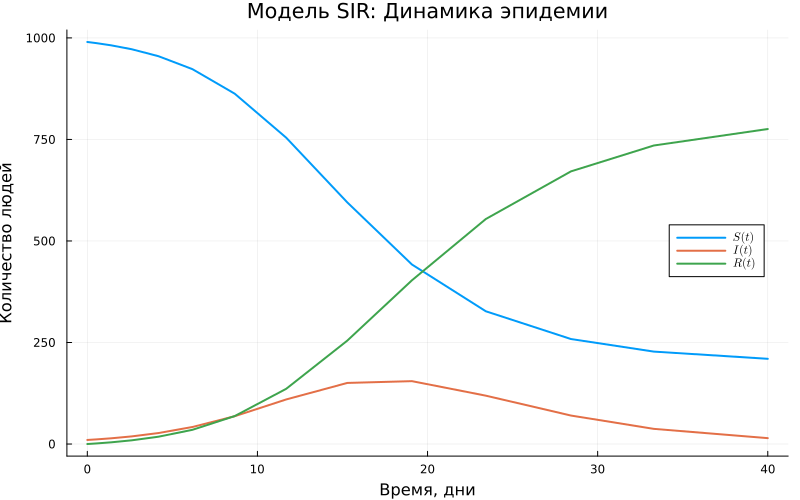

In [14]:
plt1 = @df df_ode plot(:t, [:S :I :R],
    label=[L"S(t)" L"I(t)" L"R(t)"],
    xlabel="Время, дни",
    ylabel="Количество людей",
    title="Модель SIR: Динамика эпидемии",
    linewidth=2,
    legend=:right,
    grid=true,
    size=(800, 500))

Добавление аннотаций с параметрами

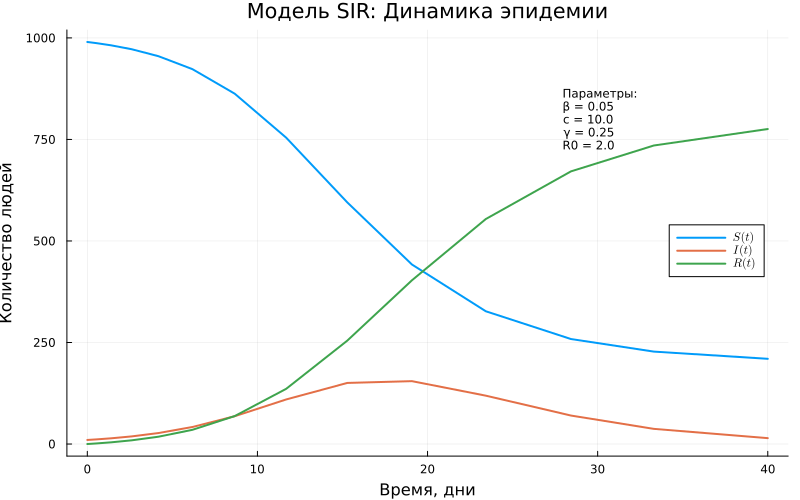

In [16]:
annotate!(plt1, maximum(df_ode.t) * 0.7, maximum(df_ode.N) * 0.8,
    text("Параметры:\nβ = $(p[1])\nc = $(p[2])\nγ = $(p[3])\nR0 = $(round(R0, digits=2))", 8, :left))

График только инфицированных (I)

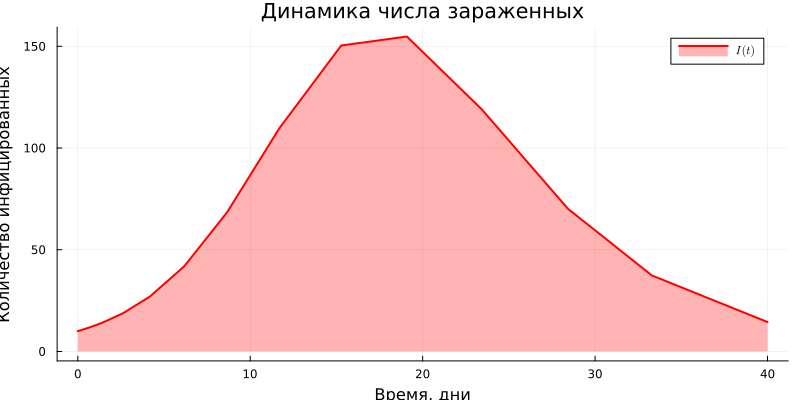

In [18]:
plt2 = @df df_ode plot(:t, :I,
    label=L"I(t)",
    xlabel="Время, дни",
    ylabel="Количество инфицированных",
    title="Динамика числа зараженных",
    color=:red,
    linewidth=2,
    fill=(0, 0.3, :red),
    grid=true,
    size=(800, 400))

Отметка пика эпидемии

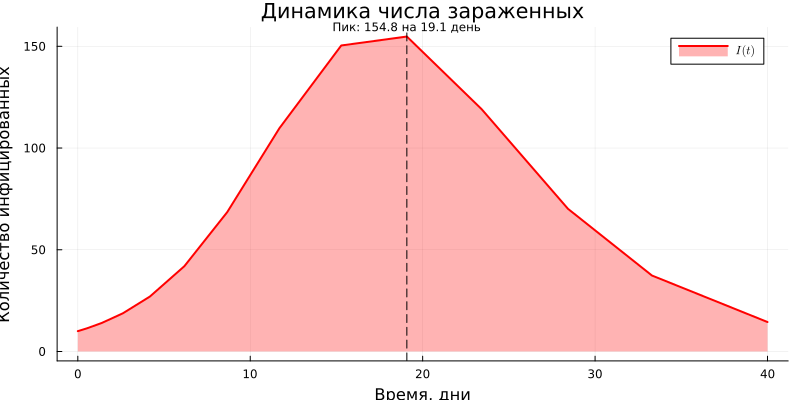

In [20]:
peak_idx = argmax(df_ode.I)
peak_time = df_ode.t[peak_idx]
peak_value = df_ode.I[peak_idx]
vline!(plt2, [peak_time], color=:black, linestyle=:dash, label=false, linewidth=1)
annotate!(plt2, peak_time, peak_value * 1.05,
    text("Пик: $(round(peak_value, digits=1)) на $(round(peak_time, digits=1)) день", 8, :top))

График в логарифмическом масштабе (для анализа экспоненциального роста)

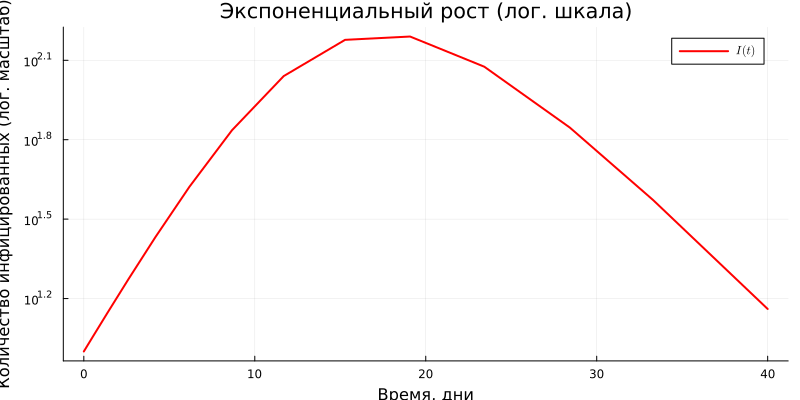

In [22]:
plt3 = @df df_ode plot(:t, :I,
    label=L"I(t)",
    xlabel="Время, дни",
    ylabel="Количество инфицированных (лог. масштаб)",
    title="Экспоненциальный рост (лог. шкала)",
    yscale=:log10,
    color=:red,
    linewidth=2,
    grid=true,
    size=(800, 400))

График долей населения (в процентах)

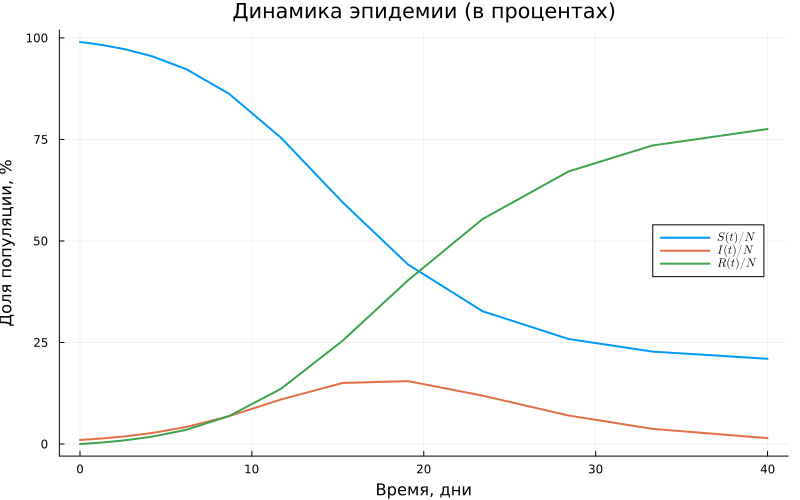

In [24]:
plt4 = @df df_ode plot(:t, [df_ode.S ./ df_ode.N .* 100 df_ode.I ./ df_ode.N .* 100 df_ode.R ./ df_ode.N .* 100],
    label=[L"S(t)/N" L"I(t)/N" L"R(t)/N"],
    xlabel="Время, дни",
    ylabel="Доля популяции, %",
    title="Динамика эпидемии (в процентах)",
    linewidth=2,
    legend=:right,
    grid=true,
    size=(800, 500))

Горизонтальная линия для порога коллективного иммунитета

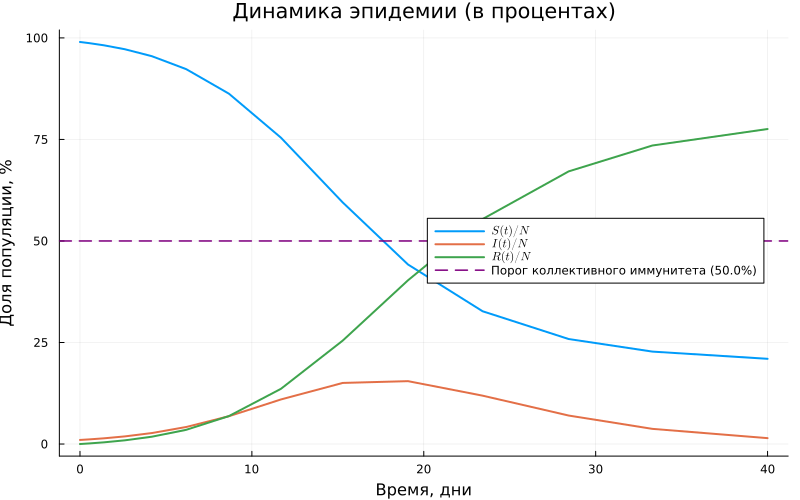

In [26]:
if R0 > 1
    herd_immunity_threshold = (1 - 1/R0) * 100
    hline!(plt4, [herd_immunity_threshold],
        color=:purple,
        linestyle=:dash,
        label="Порог коллективного иммунитета ($(round(herd_immunity_threshold, digits=1))%)",
        linewidth=1.5)
end

Фазовый портрет (I vs S)

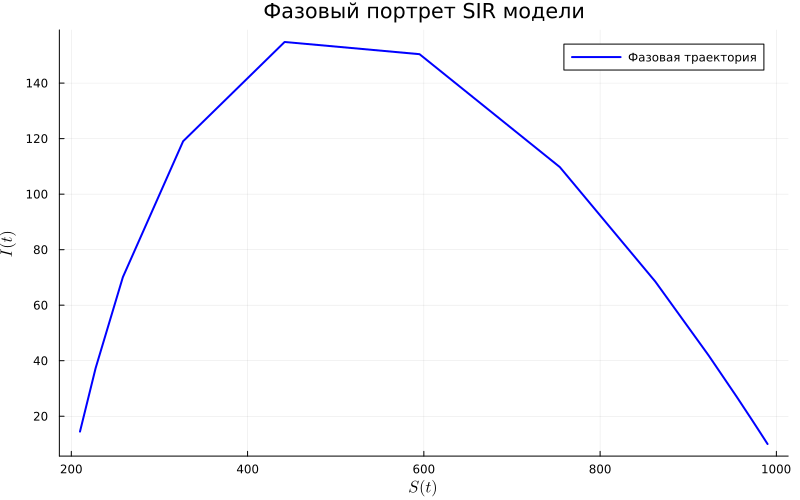

In [28]:
plt5 = plot(df_ode.S, df_ode.I,
    label="Фазовая траектория",
    xlabel=L"S(t)",
    ylabel=L"I(t)",
    title="Фазовый портрет SIR модели",
    color=:blue,
    linewidth=2,
    grid=true,
    size=(800, 500),
    legend=:topright)

Добавление стрелок направления

In [30]:
for i in 1:50:length(df_ode.S)-1
    plot!(plt5, [df_ode.S[i], df_ode.S[i+1]], [df_ode.I[i], df_ode.I[i+1]],
        arrow=:closed, color=:blue, alpha=0.5, label=false)
end

График Re - эффективного репродуктивного числа

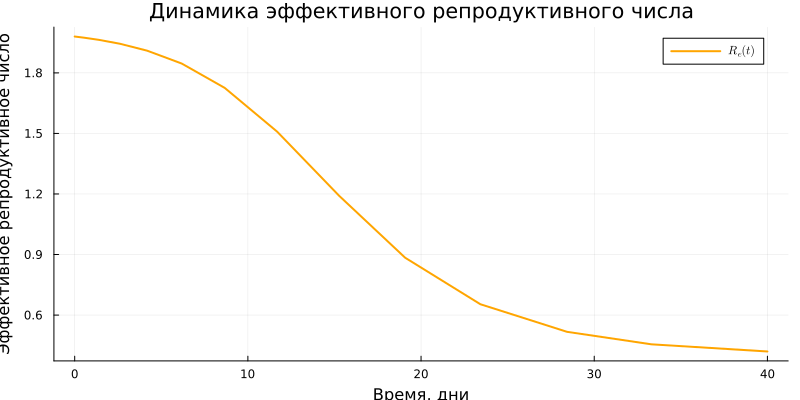

In [32]:
df_ode[!, :Re] = R0 .* df_ode.S ./ df_ode.N

plt6 = plot(df_ode.t, df_ode.Re,
    label=L"R_e(t)",
    xlabel="Время, дни",
    ylabel="Эффективное репродуктивное число",
    title="Динамика эффективного репродуктивного числа",
    color=:orange,
    linewidth=2,
    grid=true,
    size=(800, 400))

Горизонтальная линия Re = 1

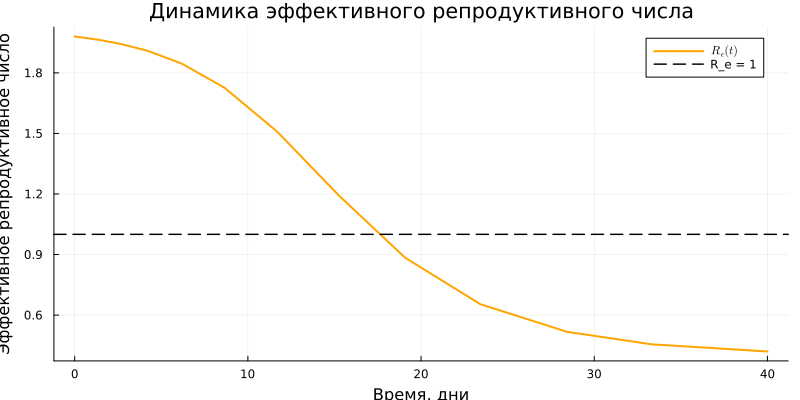

In [34]:
hline!(plt6, [1.0], color=:black, linestyle=:dash, label="R_e = 1", linewidth=1.5)

Компактная панель всех графиков

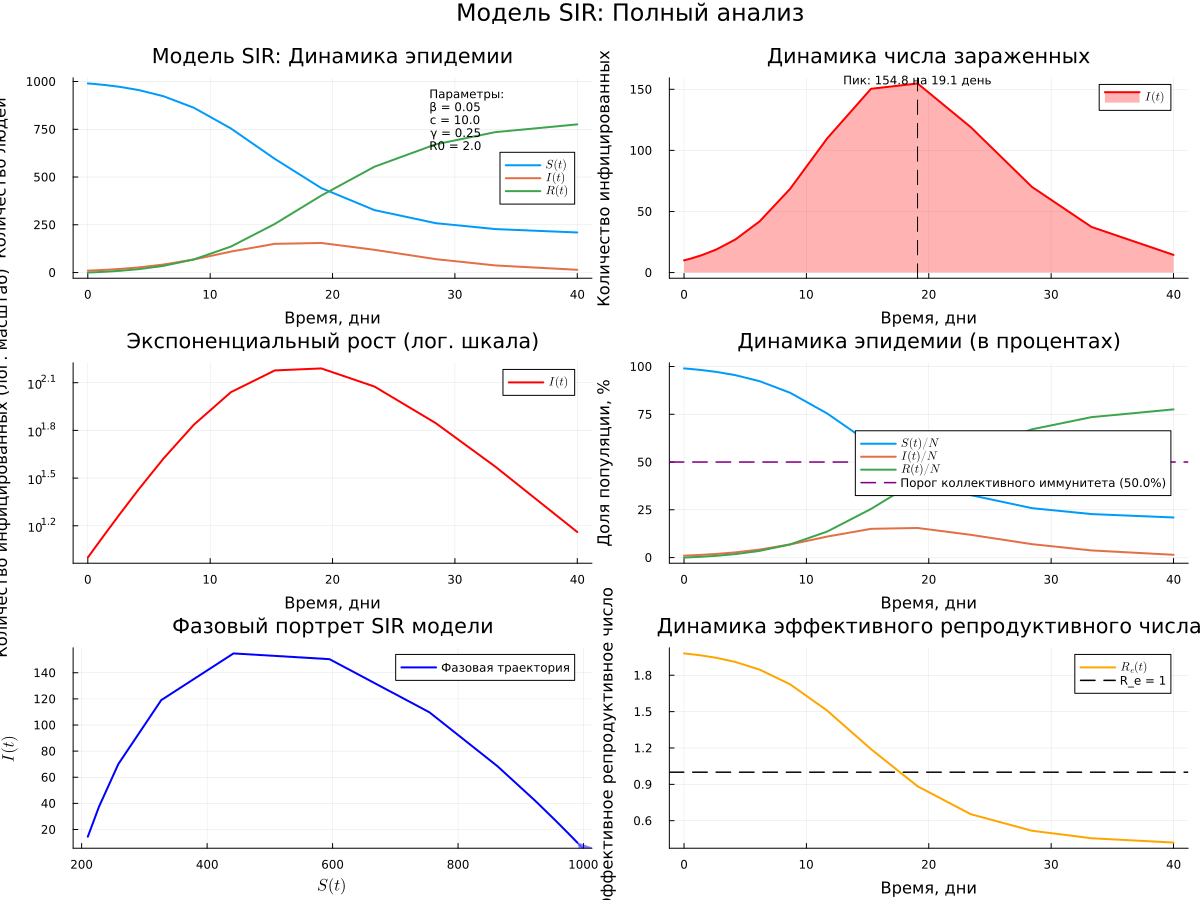

In [36]:
plt7 = plot(plt1, plt2, plt3, plt4, plt5, plt6,
    layout=(3,2),
    size=(1200, 900),
    plot_title="Модель SIR: Полный анализ")

Сохранение графиков

In [38]:
savefig(plt1, plotsdir(script_name, "sir_main.png"))
savefig(plt2, plotsdir(script_name, "sir_infected.png"))
savefig(plt3, plotsdir(script_name, "sir_log_scale.png"))
savefig(plt4, plotsdir(script_name, "sir_percentages.png"))
savefig(plt5, plotsdir(script_name, "sir_phase_portrait.png"))
savefig(plt6, plotsdir(script_name, "sir_effective_R.png"))
savefig(plt7, plotsdir(script_name, "sir_panel.png"))

"/Users/natalialarina/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab02/plots/sir_panel.png"

Бенчмарк для оценки производительности

In [40]:
println("\nБенчмарк решения:")
@benchmark solve(prob_ode, dt = δt)


Бенчмарк решения:


BenchmarkTools.Trial: 10000 samples with 5 evaluations per sample.
 Range (min … max):  5.900 μs …  6.851 ms  ┊ GC (min … max):  0.00% … 99.73%
 Time  (median):     6.550 μs              ┊ GC (median):     0.00%
 Time  (mean ± σ):   7.784 μs ± 84.086 μs  ┊ GC (mean ± σ):  15.04% ±  1.41%

      ▃▅██▇▄▄▃▃▄▃▅▆▆▅▅▄▂▃▁                                    
  ▁▂▄▇██████████████████████▇▆▅▄▄▄▄▃▃▃▂▂▂▂▂▁▁▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁ ▄
  5.9 μs         Histogram: frequency by time        8.28 μs <

 Memory estimate: 17.39 KiB, allocs estimate: 333.

Дополнительный анализ

In [42]:
println("\n== АНАЛИЗ РЕЗУЛЬТАТОВ ==")
println("Общая численность популяции (контроль): N = ", round(df_ode.N[1], digits=1))
println("Пиковое число зараженных: I_max = ", round(peak_value, digits=1))
println("Время достижения пика: t_peak = ", round(peak_time, digits=1), " дней")
println("Итоговое число переболевших: R(∞) = ", round(df_ode.R[end], digits=1))
println("Доля переболевших: ", round(df_ode.R[end]/df_ode.N[1]*100, digits=1), "%")

if R0 > 1
    println("\nТеоретический анализ:")
    println(" - Порог коллективного иммунитета: ", round((1 - 1/R0)*100, digits=1), "%")
    println(" - Теоретический пик при S/N = 1/R0 = ", round(1/R0, digits=3))
end


== АНАЛИЗ РЕЗУЛЬТАТОВ ==
Общая численность популяции (контроль): N = 1000.0
Пиковое число зараженных: I_max = 154.8
Время достижения пика: t_peak = 19.1 дней
Итоговое число переболевших: R(∞) = 775.7
Доля переболевших: 77.6%

Теоретический анализ:
 - Порог коллективного иммунитета: 50.0%
 - Теоретический пик при S/N = 1/R0 = 0.5


---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*